##  Jour 5 — Le Perceptron : Premier Modèle d'Apprentissage

###  Concept Théorique

Le **perceptron** est le premier algorithme d'apprentissage (Rosenblatt, 1958). C'est un neurone qui **apprend automatiquement ses poids** à partir des données.

L'idée : on montre des exemples au perceptron, et à chaque erreur, il ajuste ses poids pour corriger sa prédiction.

###  Intuition

Le perceptron est comme un **étudiant** :
1. Il fait une prédiction (examen)
2. On lui dit s'il a bon ou faux (correction)
3. S'il a faux, il ajuste sa compréhension (mise à jour des poids)
4. On recommence jusqu'à ce qu'il ait tout bon

###  Formules Essentielles

**Prédiction :**
$$\hat{y} = \text{step}(\mathbf{w}^T \mathbf{x} + b)$$

**Règle de mise à jour du Perceptron :**
$$w_i \leftarrow w_i + \alpha \cdot (y - \hat{y}) \cdot x_i$$
$$b \leftarrow b + \alpha \cdot (y - \hat{y})$$

Où $(y - \hat{y})$ est l'erreur.

###  Implémentation From Scratch


=== Perceptron pour la porte AND ===

  Époque   1 : 1 erreur(s)
  Époque   2 : 3 erreur(s)
  Époque   3 : 3 erreur(s)
  Époque   4 : 2 erreur(s)
  Époque   5 : 1 erreur(s)

  ✅ Convergence atteinte à l'époque 6 !

Poids finaux : [0.2 0.1]
Biais final  : -0.2

Test :
  [0 0] → prédit: 0, attendu: 0 ✅
  [0 1] → prédit: 0, attendu: 0 ✅
  [1 0] → prédit: 0, attendu: 0 ✅
  [1 1] → prédit: 1, attendu: 1 ✅

=== Perceptron pour la porte OR ===

  Époque   1 : 1 erreur(s)
  Époque   2 : 2 erreur(s)
  Époque   3 : 1 erreur(s)
  Époque   4 : 0 erreur(s)

  ✅ Convergence atteinte à l'époque 4 !

Test :
  [0 0] → prédit: 0, attendu: 0 ✅
  [0 1] → prédit: 1, attendu: 1 ✅
  [1 0] → prédit: 1, attendu: 1 ✅
  [1 1] → prédit: 1, attendu: 1 ✅

=== Perceptron pour XOR (ça ne marchera PAS) ===

  Époque   1 : 2 erreur(s)
  Époque   2 : 3 erreur(s)
  Époque   3 : 4 erreur(s)
  Époque   4 : 4 erreur(s)
  Époque   5 : 4 erreur(s)
  Époque  11 : 4 erreur(s)
  Époque  21 : 4 erreur(s)
  Époque  31 : 4 erreur(s

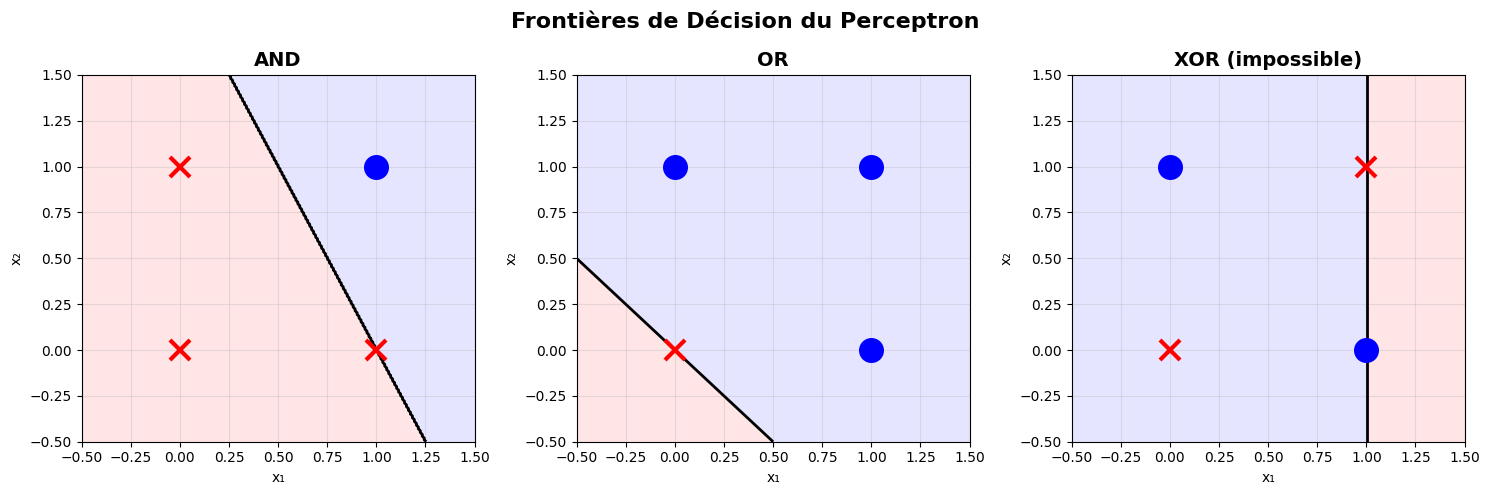

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOUR 5 : Le Perceptron
# ============================================================

class Perceptron:
    """
    Perceptron : le premier modèle d'apprentissage supervisé.
    Peut résoudre des problèmes linéairement séparables.
    """

    def __init__(self, n_features, learning_rate=0.1):
        """
        Args:
            n_features: nombre de caractéristiques en entrée
            learning_rate: vitesse d'apprentissage (alpha)
        """
        self.weights = np.zeros(n_features)  # poids initialisés à 0
        self.bias = 0.0
        self.lr = learning_rate

    def predict(self, x):
        """
        Fait une prédiction pour un seul exemple.
        
        Args:
            x: vecteur de caractéristiques
        
        Returns:
            0 ou 1
        """
        z = np.dot(self.weights, x) + self.bias
        return 1 if z > 0 else 0

    def train(self, X, y, n_epochs=100):
        """
        Entraîne le perceptron sur les données.
        
        Args:
            X: matrice de données (n_samples, n_features)
            y: vecteur de labels (n_samples,)
            n_epochs: nombre de passages sur les données
        
        Returns:
            Liste des erreurs par époque
        """
        errors_per_epoch = []

        for epoch in range(n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                # 1. Faire une prédiction
                prediction = self.predict(xi)
                
                # 2. Calculer l'erreur
                error = yi - prediction
                
                # 3. Mettre à jour les poids SI erreur != 0
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    errors += 1

            errors_per_epoch.append(errors)

            # Afficher la progression
            if epoch < 5 or epoch % 10 == 0:
                print(f"  Époque {epoch+1:>3} : {errors} erreur(s)")

            # Arrêt anticipé si aucune erreur
            if errors == 0:
                print(f"\n  ✅ Convergence atteinte à l'époque {epoch + 1} !")
                break

        return errors_per_epoch

# --- Exemple 1 : Porte logique AND ---
print("=== Perceptron pour la porte AND ===\n")

X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])
y_and = np.array([0, 0, 0, 1])  # AND : 1 seulement si les deux sont 1

perceptron_and = Perceptron(n_features=2, learning_rate=0.1)
errors_and = perceptron_and.train(X_and, y_and, n_epochs=100)

print(f"\nPoids finaux : {perceptron_and.weights}")
print(f"Biais final  : {perceptron_and.bias}")
print("\nTest :")
for xi, yi in zip(X_and, y_and):
    pred = perceptron_and.predict(xi)
    status = "✅" if pred == yi else "❌"
    print(f"  {xi} → prédit: {pred}, attendu: {yi} {status}")

# --- Exemple 2 : Porte logique OR ---
print("\n=== Perceptron pour la porte OR ===\n")

y_or = np.array([0, 1, 1, 1])

perceptron_or = Perceptron(n_features=2, learning_rate=0.1)
errors_or = perceptron_or.train(X_and, y_or, n_epochs=100)

print(f"\nTest :")
for xi, yi in zip(X_and, y_or):
    pred = perceptron_or.predict(xi)
    status = "✅" if pred == yi else "❌"
    print(f"  {xi} → prédit: {pred}, attendu: {yi} {status}")

# --- Exemple 3 : Le problème XOR (impossible !) ---
print("\n=== Perceptron pour XOR (ça ne marchera PAS) ===\n")

y_xor = np.array([0, 1, 1, 0])

perceptron_xor = Perceptron(n_features=2, learning_rate=0.1)
errors_xor = perceptron_xor.train(X_and, y_xor, n_epochs=100)

print(f"\nTest :")
for xi, yi in zip(X_and, y_xor):
    pred = perceptron_xor.predict(xi)
    status = "✅" if pred == yi else "❌"
    print(f"  {xi} → prédit: {pred}, attendu: {yi} {status}")

print("\n💡 Le XOR n'est PAS linéairement séparable.")
print("   → On a besoin de PLUSIEURS couches (réseau profond) !")

# --- Visualisation des frontières de décision ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["AND", "OR", "XOR (impossible)"]
perceptrons = [perceptron_and, perceptron_or, perceptron_xor]
labels = [y_and, y_or, y_xor]

for ax, title, perc, y in zip(axes, titles, perceptrons, labels):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    Z = np.array([perc.predict(np.array([a, b]))
                  for a, b in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=['#FFCCCC', '#CCCCFF'], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    for xi, yi in zip(X_and, y):
        color = 'blue' if yi == 1 else 'red'
        marker = 'o' if yi == 1 else 'x'
        ax.plot(xi[0], xi[1], marker, color=color, markersize=15, markeredgewidth=3)
    
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.grid(True, alpha=0.3)

plt.suptitle("Frontières de Décision du Perceptron", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("perceptron_decision_boundaries.png", dpi=150)
plt.show()


###  Ce qu'il faut retenir du Jour 5

> **Le perceptron est puissant mais limité** : il ne peut résoudre que les problèmes **linéairement séparables** (séparables par une droite). Le XOR montre qu'un seul neurone ne suffit pas.
>
> **Solution** → Empiler plusieurs couches de neurones = **réseau de neurones** ! C'est ce qu'on fera à partir du Jour 11.

---

---

